In [1]:
from tensorflow import keras
import os
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, precision_recall_curve

In [2]:
def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

def load_images(img_dir, target_size=None):
    images = []
    for filename in os.listdir(img_dir):
        if filename.endswith('.png'):
            path = os.path.join(img_dir, filename)
            img = Image.open(path)
            
            if target_size:
                img = img.resize(target_size, Image.BICUBIC)
            
            img = np.array(img)
            images.append(img)
    return np.array(images)

def show_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Matriz de Confusión');

def show_precision_recall_curve(y_true, y_proba, punto_corte=0.5):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)

    plt.plot(thr, rec[:-1], label='recall')
    plt.plot(thr, prec[:-1], label='precision')
    plt.xlabel('Punto de corte')
    plt.vlines(punto_corte, 0, 1, colors='red', linestyles='dashed', label='corte')
    plt.grid()
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.legend()
    plt.show()

In [3]:
dataset = 'crudos'

In [4]:
X_propios = load_images(f'./audios_propios/ciclos_energy_based_mel_images/pad/', target_size=(372, 128))

# Datos originales

In [34]:
test_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/test_imgs'

X_test, y_test = load_image_dataset(test_dir, target_size=(372, 128))

In [36]:
modelo = keras.models.load_model(f'./neural_network/modelos/{dataset}_fine_tuned.keras')

In [37]:
modelo.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 372, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 372, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 128, 372, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 372, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 12, 1280)    │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,654,021 (25.38 MB)

 Trainable params: 2,025,793 (7.73 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 4,051,588 (15.46 MB)

In [38]:
modelo.evaluate(X_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 440ms/step - auc_1: 0.8048 - loss: 0.5708 - recall_1: 0.7615


[0.5708121061325073, 0.804835319519043, 0.76145339012146]

In [39]:
preds = modelo.predict(X_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 471ms/step


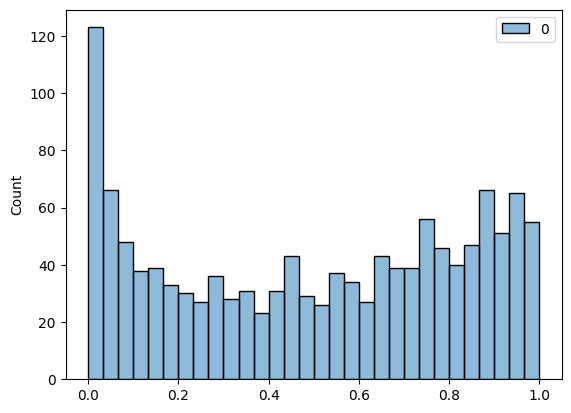

In [40]:
sns.histplot(preds, bins=30);

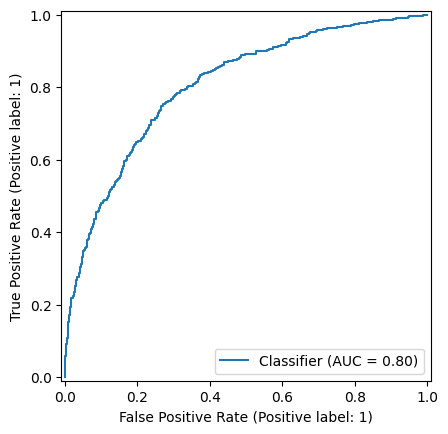

In [41]:
RocCurveDisplay.from_predictions(y_test, preds);

In [42]:
y_pred = (preds >= 0.5).astype(int)

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.71      0.74       663
           1       0.72      0.76      0.74       633

    accuracy                           0.74      1296
   macro avg       0.74      0.74      0.74      1296
weighted avg       0.74      0.74      0.74      1296



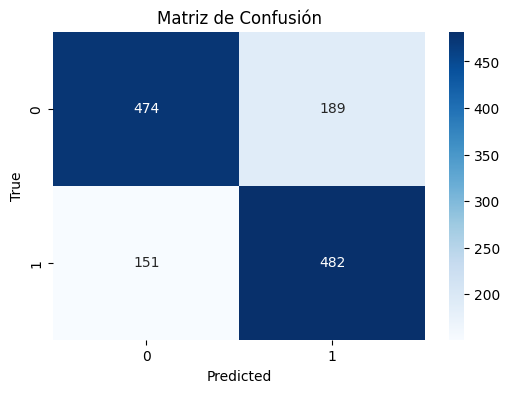

In [44]:
show_confusion_matrix(y_test, y_pred)

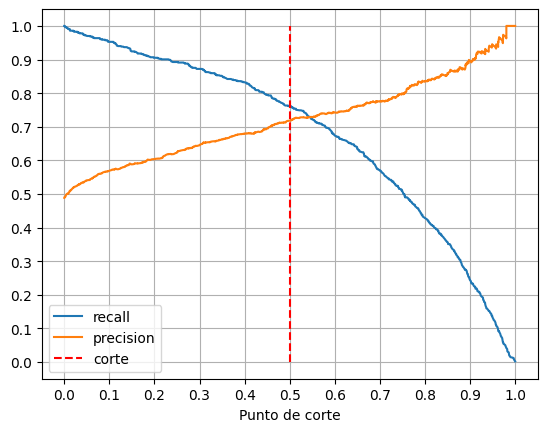

In [45]:
show_precision_recall_curve(y_test, preds, punto_corte=0.5)

In [46]:
preds_propios = modelo.predict(X_propios)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step


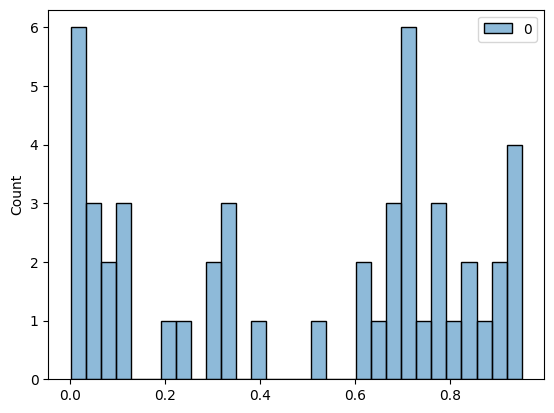

In [47]:
sns.histplot(preds_propios, bins=30);

In [48]:
files = os.listdir(f'./audios_propios/ciclos_energy_based_mel_images/pad/')
df_propios = pd.DataFrame({'filename': files, 'prediction': preds_propios.flatten()})
df_propios.sort_values(by='prediction', ascending=False, inplace=True)
df_propios

,filename,prediction
9,respiracion2_ciclo_3.png,0.950832
17,respiracion3_ciclo_5.png,0.950261
11,respiracion2_ciclo_5.png,0.940656
21,respiracion4_ciclo_3.png,0.931532
19,respiracion4_ciclo_1.png,0.907411
0,respiracion1_ciclo_1.png,0.888629
39,respiracion7_ciclo_1.png,0.861130
2,respiracion1_ciclo_3.png,0.840376
20,respiracion4_ciclo_2.png,0.833339
10,respiracion2_ciclo_4.png,0.801327


# Datos aumentados

In [50]:
test_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/test_aug_imgs'

X_test, y_test = load_image_dataset(test_dir, target_size=(372, 128))

In [49]:
modelo = keras.models.load_model(f'./neural_network/modelos/{dataset}_aug_fine_tuned.keras')

In [51]:
preds = modelo.predict(X_test)

114/114 ━━━━━━━━━━━━━━━━━━━━ 56s 479ms/step


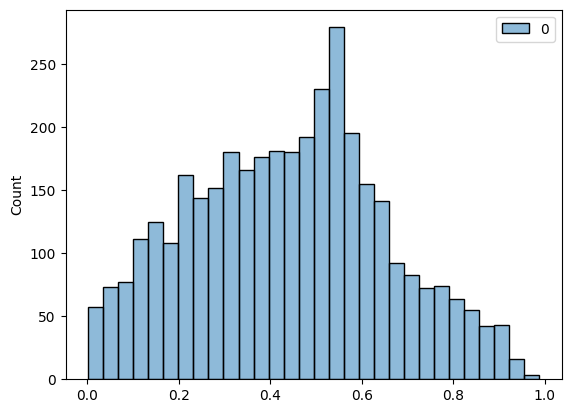

In [52]:
sns.histplot(preds, bins=30);

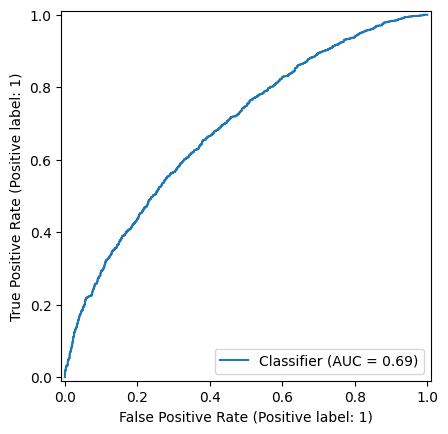

In [53]:
RocCurveDisplay.from_predictions(y_test, preds);

In [54]:
y_pred = (preds >= 0.5).astype(int)

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.71      0.67      1861
           1       0.65      0.56      0.60      1767

    accuracy                           0.64      3628
   macro avg       0.64      0.63      0.63      3628
weighted avg       0.64      0.64      0.63      3628



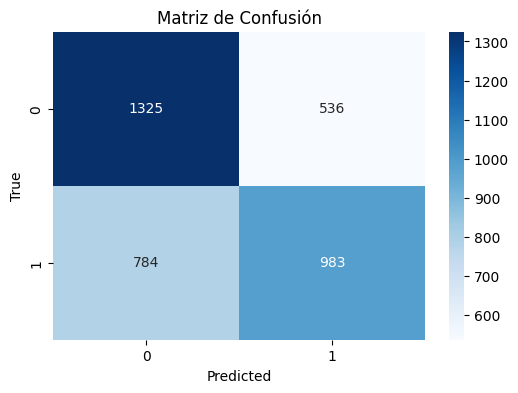

In [56]:
show_confusion_matrix(y_test, y_pred)

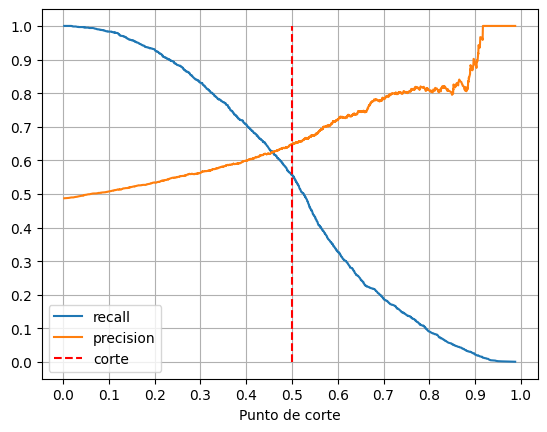

In [57]:
show_precision_recall_curve(y_test, preds, punto_corte=0.5)

In [58]:
preds_propios = modelo.predict(X_propios)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step


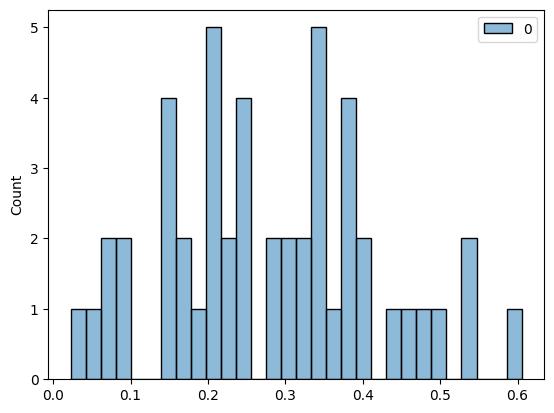

In [59]:
sns.histplot(preds_propios, bins=30);

In [60]:
files = os.listdir(f'./audios_propios/ciclos_energy_based_mel_images/pad/')
df_propios = pd.DataFrame({'filename': files, 'prediction': preds_propios.flatten()})
df_propios.sort_values(by='prediction', ascending=False, inplace=True)
df_propios

,filename,prediction
0,respiracion1_ciclo_1.png,0.605258
6,respiracion1_ciclo_7.png,0.539464
9,respiracion2_ciclo_3.png,0.537458
19,respiracion4_ciclo_1.png,0.499736
31,respiracion5_ciclo_6.png,0.471018
13,respiracion3_ciclo_1.png,0.451733
35,respiracion6_ciclo_4.png,0.444007
23,respiracion4_ciclo_5.png,0.410880
27,respiracion5_ciclo_2.png,0.394247
21,respiracion4_ciclo_3.png,0.389356
